# Credit Risk Analysis — Phase 1: Exploratory Data Analysis
**Project:** Credit Risk Scorecard for Loan Default Prediction  
**Goal:** Understand the data, find patterns, generate business insights  
**Dataset:** Give Me Some Credit (Kaggle)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
%matplotlib inline

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
df = pd.read_csv('cs-training.csv', index_col=0)

print('Shape:', df.shape)
print('\nFirst look:')
df.head()

Shape: (150000, 11)

First look:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
print('Column Names & Data Types:')
print(df.dtypes)
print('\nBasic Statistics:')
df.describe()

Column Names & Data Types:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

Basic Statistics:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## Data Quality Audit

In [4]:
print('=' * 55)
print('DATA QUALITY AUDIT')
print('=' * 55)

print(f'\nTotal Records: {len(df):,}')

dupes = df.duplicated().sum()
print(f'Duplicate Rows: {dupes}')

print(f'\nMissing Values:')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
for col, count in missing.items():
    if count > 0:
        print(f'  {col}: {count:,} missing ({missing_pct[col]:.1f}%)')

print(f'\nAge Issues:')
print(f'  Age = 0: {(df["age"] == 0).sum()} records')
print(f'  Age < 18: {(df["age"] < 18).sum()} records')
print(f'  Age > 100: {(df["age"] > 100).sum()} records')

print(f'\nUtilization Issues:')
print(f'  Utilization > 1: {(df["RevolvingUtilizationOfUnsecuredLines"] > 1).sum():,} records')
print(f'  Max utilization value: {df["RevolvingUtilizationOfUnsecuredLines"].max():.2f}')

print(f'\nOutlier Check:')
print(f'  Max DebtRatio: {df["DebtRatio"].max():,.2f}')
print(f'  Max MonthlyIncome: {df["MonthlyIncome"].max():,.2f}')
print(f'  Max NumberOfDependents: {df["NumberOfDependents"].max()}')
print('\n' + '=' * 55)

DATA QUALITY AUDIT

Total Records: 150,000
Duplicate Rows: 609

Missing Values:
  MonthlyIncome: 29,731 missing (19.8%)
  NumberOfDependents: 3,924 missing (2.6%)

Age Issues:
  Age = 0: 1 records
  Age < 18: 1 records
  Age > 100: 13 records

Utilization Issues:
  Utilization > 1: 3,321 records
  Max utilization value: 50708.00

Outlier Check:
  Max DebtRatio: 329,664.00
  Max MonthlyIncome: 3,008,750.00
  Max NumberOfDependents: 20.0



## Data Preprocessing & Cleaning

In [5]:
df_clean = df.copy()

# Step 1: Remove Duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Duplicates removed: {before - len(df_clean)}')

# Step 2: Fix Age Issues
before = len(df_clean)
df_clean = df_clean[df_clean['age'] >= 18]
df_clean = df_clean[df_clean['age'] <= 100]
print(f'Bad age records removed: {before - len(df_clean)}')

# Step 3: Fill Missing Values
median_income = df_clean['MonthlyIncome'].median()
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(median_income)
print(f'MonthlyIncome nulls filled with median: ${median_income:,.0f}')

median_deps = df_clean['NumberOfDependents'].median()
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(median_deps)
print(f'NumberOfDependents nulls filled with median: {median_deps}')

# Step 4: Cap Outliers
df_clean['RevolvingUtilizationOfUnsecuredLines'] = df_clean['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)

Q1 = df_clean['DebtRatio'].quantile(0.25)
Q3 = df_clean['DebtRatio'].quantile(0.75)
IQR = Q3 - Q1
debt_cap = Q3 + 3 * IQR
df_clean['DebtRatio'] = df_clean['DebtRatio'].clip(0, debt_cap)

Q1 = df_clean['MonthlyIncome'].quantile(0.25)
Q3 = df_clean['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1
income_cap = Q3 + 3 * IQR
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].clip(0, income_cap)

df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].clip(0, 10)

print('\n' + '=' * 55)
print('CLEANING COMPLETE')
print('=' * 55)
print(f'Original records:  150,000')
print(f'Clean records:     {len(df_clean):,}')
print(f'Records removed:   {150000 - len(df_clean):,}')
print(f'Missing values remaining: {df_clean.isnull().sum().sum()}')
print('=' * 55)

Duplicates removed: 609
Bad age records removed: 14
MonthlyIncome nulls filled with median: $5,400
NumberOfDependents nulls filled with median: 0.0

CLEANING COMPLETE
Original records:  150,000
Clean records:     149,377
Records removed:   623
Missing values remaining: 0


## EDA — Target Variable

Default Distribution:
No Default (0): 139,369 (93.3%)
Defaulted  (1): 10,008 (6.7%)

Class Imbalance Ratio: 13.9:1


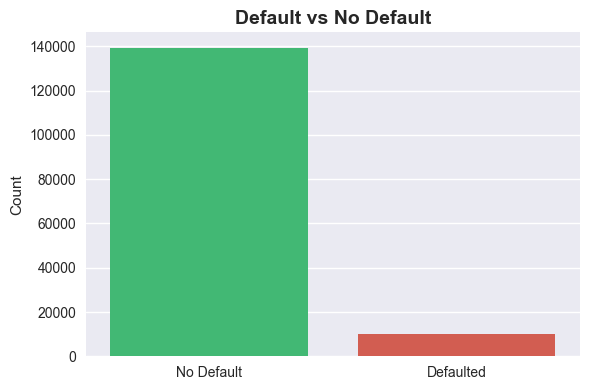


BUSINESS INSIGHT:
Only 6.7% of applicants defaulted — severe class imbalance.
A naive model predicting "no default" every time would be 93% accurate but useless.
We will use SMOTE to handle this in the modeling phase.


In [6]:
default_rate = df_clean['SeriousDlqin2yrs'].value_counts()
default_pct = df_clean['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print('Default Distribution:')
print(f'No Default (0): {default_rate[0]:,} ({default_pct[0]:.1f}%)')
print(f'Defaulted  (1): {default_rate[1]:,} ({default_pct[1]:.1f}%)')
print(f'\nClass Imbalance Ratio: {default_rate[0]/default_rate[1]:.1f}:1')

plt.figure(figsize=(6,4))
sns.countplot(x='SeriousDlqin2yrs', data=df_clean, hue='SeriousDlqin2yrs',
              palette={0:'#2ecc71', 1:'#e74c3c'}, legend=False)
plt.title('Default vs No Default', fontsize=14, fontweight='bold')
plt.xticks([0,1], ['No Default', 'Defaulted'])
plt.xlabel('')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nBUSINESS INSIGHT:')
print(f'Only {default_pct[1]:.1f}% of applicants defaulted — severe class imbalance.')
print('A naive model predicting "no default" every time would be 93% accurate but useless.')
print('We will use SMOTE to handle this in the modeling phase.')

## EDA — Age Analysis

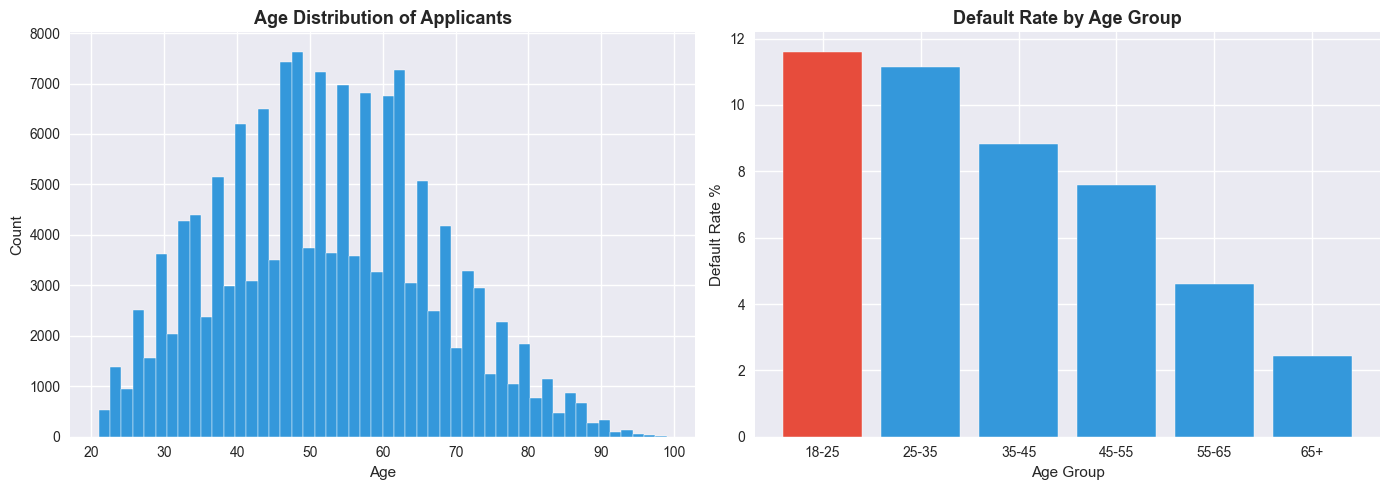

BUSINESS INSIGHT:
Age group 18-25 has the highest default rate at 11.6%.
Bank should apply stricter screening criteria for this segment.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
axes[0].hist(df_clean['age'], bins=50, color='#3498db', edgecolor='white')
axes[0].set_title('Age Distribution of Applicants', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Default rate by age group
df_clean['age_group'] = pd.cut(df_clean['age'],
                                bins=[17, 25, 35, 45, 55, 65, 100],
                                labels=['18-25', '25-35', '35-45', '45-55', '55-65', '65+'])

age_default = df_clean.groupby('age_group', observed=True)['SeriousDlqin2yrs'].mean() * 100
colors = ['#e74c3c' if v == age_default.max() else '#3498db' for v in age_default.values]
axes[1].bar(age_default.index, age_default.values, color=colors, edgecolor='white')
axes[1].set_title('Default Rate by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Default Rate %')

plt.tight_layout()
plt.savefig('plots/02_age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

highest_age = age_default.idxmax()
highest_rate = age_default.max()
print(f'BUSINESS INSIGHT:')
print(f'Age group {highest_age} has the highest default rate at {highest_rate:.1f}%.')
print(f'Bank should apply stricter screening criteria for this segment.')

## EDA — Income & Debt Analysis

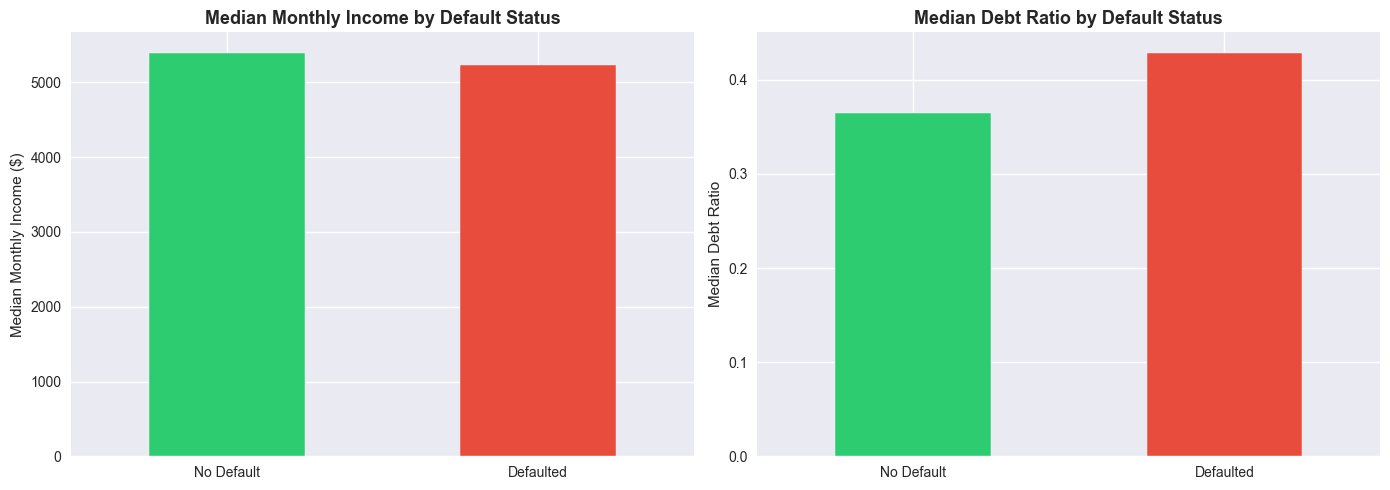

BUSINESS INSIGHT:
Defaulters earn $5,228/month median vs $5,400/month for non-defaulters.
Income is a strong predictor — 3% income gap between groups.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income by default status
df_clean.groupby('SeriousDlqin2yrs')['MonthlyIncome'].median().plot(
    kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0].set_title('Median Monthly Income by Default Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['No Default', 'Defaulted'], rotation=0)
axes[0].set_ylabel('Median Monthly Income ($)')

# Debt ratio by default status
df_clean.groupby('SeriousDlqin2yrs')['DebtRatio'].median().plot(
    kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[1].set_title('Median Debt Ratio by Default Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_xticklabels(['No Default', 'Defaulted'], rotation=0)
axes[1].set_ylabel('Median Debt Ratio')

plt.tight_layout()
plt.savefig('plots/03_income_debt_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

inc_no_default = df_clean[df_clean['SeriousDlqin2yrs']==0]['MonthlyIncome'].median()
inc_default = df_clean[df_clean['SeriousDlqin2yrs']==1]['MonthlyIncome'].median()
print(f'BUSINESS INSIGHT:')
print(f'Defaulters earn ${inc_default:,.0f}/month median vs ${inc_no_default:,.0f}/month for non-defaulters.')
print(f'Income is a strong predictor — {((inc_no_default-inc_default)/inc_no_default)*100:.0f}% income gap between groups.')

## EDA — Late Payments Analysis

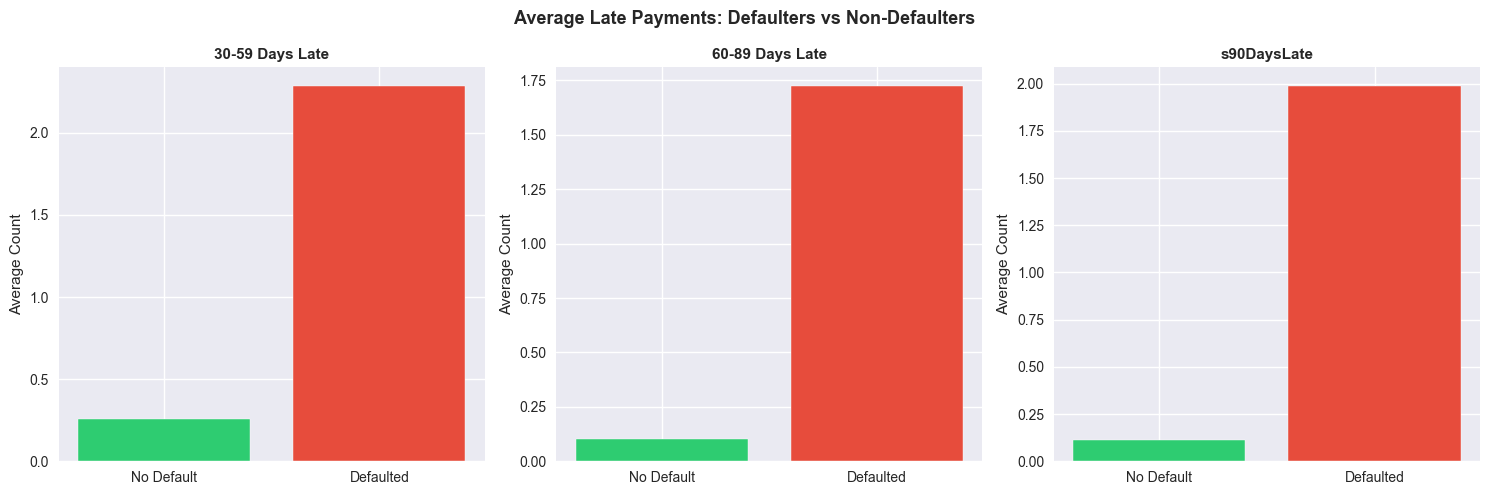

BUSINESS INSIGHT:
Defaulters have significantly more late payments across all categories.
Payment history is one of the strongest predictors of future default.


In [9]:
late_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTime60-89DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(late_cols):
    avg_by_default = df_clean.groupby('SeriousDlqin2yrs')[col].mean()
    axes[i].bar(['No Default', 'Defaulted'], avg_by_default.values,
                color=['#2ecc71','#e74c3c'], edgecolor='white')
    axes[i].set_title(col.replace('NumberOfTime','').replace('DaysPastDueNotWorse',' Days Late'),
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Average Count')

plt.suptitle('Average Late Payments: Defaulters vs Non-Defaulters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_late_payments.png', dpi=150, bbox_inches='tight')
plt.show()

print('BUSINESS INSIGHT:')
print('Defaulters have significantly more late payments across all categories.')
print('Payment history is one of the strongest predictors of future default.')

## EDA — Correlation Heatmap

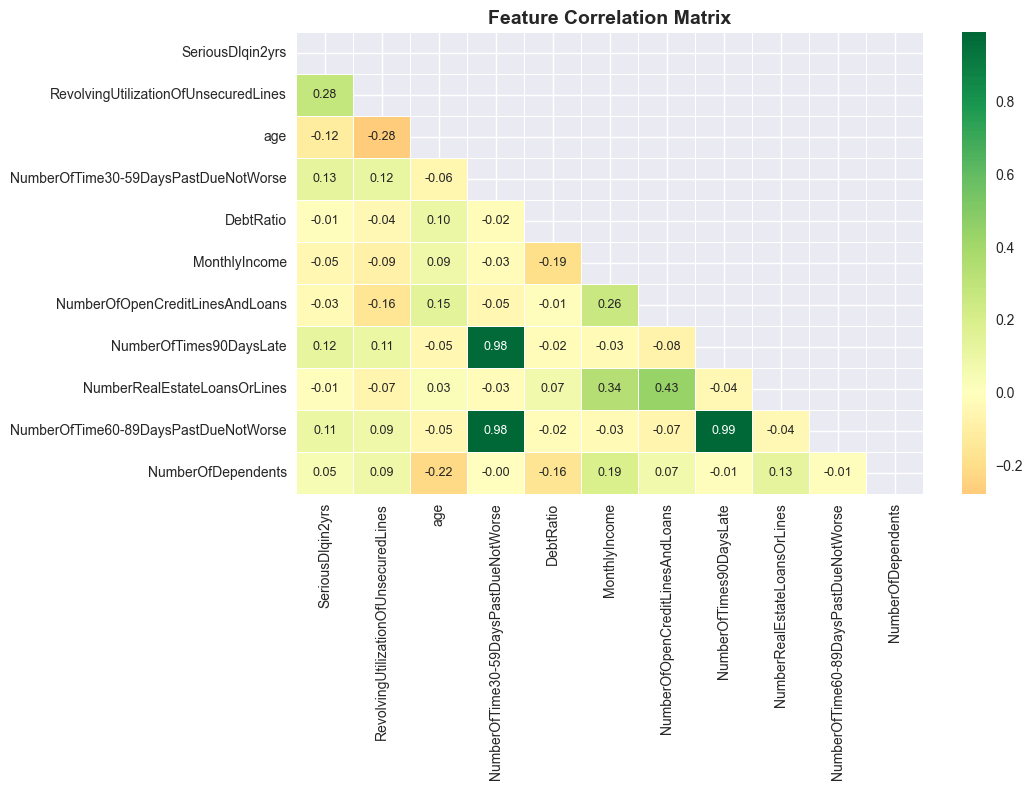

Correlation with Default (SeriousDlqin2yrs):
RevolvingUtilizationOfUnsecuredLines    0.279359
NumberOfTime30-59DaysPastDueNotWorse    0.131511
NumberOfTimes90DaysLate                 0.122501
NumberOfTime60-89DaysPastDueNotWorse    0.106262
NumberOfDependents                      0.046613
DebtRatio                              -0.006863
NumberRealEstateLoansOrLines           -0.007620
NumberOfOpenCreditLinesAndLoans        -0.030534
MonthlyIncome                          -0.052763
age                                    -0.115807
Name: SeriousDlqin2yrs, dtype: float64


In [10]:
numeric_df = df_clean.drop(columns=['age_group'])

plt.figure(figsize=(11, 8))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

target_corr = corr['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs').sort_values(ascending=False)
print('Correlation with Default (SeriousDlqin2yrs):')
print(target_corr)

In [11]:
# Save clean data for next notebook
df_clean.to_csv('data_clean.csv', index=False)
print('Clean data saved to data_clean.csv')
print(f'Final shape: {df_clean.shape}')

Clean data saved to data_clean.csv
Final shape: (149377, 12)
